# Global Development Index Analysis (Gapminder, 1952-2007)

For this project I wanted to move beyond looking at a single raw indicator (like GDP per capita
alone) and instead build a composite score that blends multiple dimensions of a country's
development into one number. I picked the **Gapminder** dataset because it tracks population,
life expectancy, and GDP per capita for 142 countries across more than 50 years (1952-2007),
which gives enough history to actually look at long-term change, not just a single snapshot.

I call the composite score the **Development Index**. A 0-100 score per country/year that
combines economic strength, health, and population scale.

**Contents**
1. Setup
2. Load & process the data (with a data-quality check)
3. Global rankings, extremes, and threshold filtering
4. Continent-level analysis (including GDP quartiles)
5. Country deep-dives & comparisons
6. Correlation & distribution analysis
7. Biggest movers over time (absolute and percentage change) + decade trends
8. Custom weighting experiment


I'm running this notebook from the `notebooks/` folder, so the paths below are relative to it.

## 1. Setup

I built the actual data loading and scoring logic into a small package (`wellbeing`) rather than
writing everything inline in the notebook, so the notebook can stay focused on exploration and
the reusable logic lives in one place.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from wellbeing import DevelopmentHandler, DevelopmentVisualizer

pd.set_option('display.max_columns', None)

## 2. Load & process the data

I start by loading the raw CSV and immediately computing the Development Index, since almost
every later section depends on that column existing. Internally, `compute_development_index`
normalizes GDP per capita and life expectancy **within each year** rather than across the whole
1952-2007 range. I did it this way because comparing a 1952 country to a 2007 range would be
misleading; countries should only be judged against their contemporaries.

In [2]:
dh = DevelopmentHandler(data_dir='../data')
dh.load_data()
dh.compute_development_index()
dh.data.head()

,country,year,pop,continent,lifeExp,gdpPercap,gdpPercap_log,pop_log,pop_log_inv,gdpPercap_norm,lifeExp_norm,pop_log_inv_norm,development_index
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314,6.659865,15.946754,-15.946754,0.162406,0.000000,0.458703,11.895280
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030,6.711562,16.039154,-16.039154,0.153184,0.000000,0.457756,11.470861
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710,6.750049,16.144454,-16.144454,0.156422,0.000000,0.452053,11.559521
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138,6.730060,16.261154,-16.261154,0.160229,0.000000,0.450765,11.717974
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106,6.607975,16.386554,-16.386554,0.127136,0.017497,0.448973,10.998236


Before going further, I wanted a quick feel for the shape of the dataset how many countries, how many years, and which continents are represented.

In [3]:
print(f"Countries: {dh.data['country'].nunique()}")
print(f"Years covered: {sorted(dh.data['year'].unique())}")
print(f"Continents: {sorted(dh.data['continent'].unique())}")

Countries: 142
Years covered: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']


### Summary statistics (most recent year)

In [4]:
dh.get_summary_statistics()

,gdpPercap,lifeExp,pop,development_index
count,142.00,142.00,1.420000e+02,142.00
mean,11680.07,67.01,4.402122e+07,60.00
std,12859.94,12.07,1.476214e+08,23.27
min,277.55,39.61,1.995790e+05,10.60
25%,1624.84,57.16,4.508034e+06,40.94
50%,6124.37,71.94,1.051753e+07,64.47
75%,18008.84,76.41,3.121004e+07,78.62
max,49357.19,82.60,1.318683e+09,95.94


### Data quality check

I ran a basic data-quality check before trusting any of the numbers above checking for missing
values, unexpected dtypes, and how many unique values each column has. The dataset turned out to
be clean, but I wanted this step documented rather than just assumed.

In [5]:
dh.get_data_quality_report()

,column,dtype,missing_values,missing_pct,unique_values
0,country,str,0,0.0,142
1,year,int64,0,0.0,12
2,pop,float64,0,0.0,1704
3,continent,str,0,0.0,5
4,lifeExp,float64,0,0.0,1626
5,gdpPercap,float64,0,0.0,1704
6,gdpPercap_log,float64,0,0.0,1704
7,pop_log,float64,0,0.0,1704
8,pop_log_inv,float64,0,0.0,1704
9,gdpPercap_norm,float64,0,0.0,1682


## 3. Global rankings

The first real question I wanted to answer: which countries come out on top once GDP, health,
and population are combined into one score?

In [6]:
top15_2007 = dh.get_top_countries(n=15, year=2007)
top15_2007

,rank,country,continent,year,gdpPercap,lifeExp,pop,development_index
0,1,Iceland,Europe,2007,36180.78919,81.757,301931.0,95.944549
1,2,Norway,Europe,2007,49357.19017,80.196,4627926.0,93.906479
2,3,"Hong Kong, China",Asia,2007,39724.97867,82.208,6980412.0,93.658300
3,4,Singapore,Asia,2007,47143.17964,79.972,4553009.0,93.291663
4,5,Switzerland,Europe,2007,37506.41907,81.701,7554661.0,92.538224
5,6,Kuwait,Asia,2007,47306.98978,77.588,2505559.0,91.505385
6,7,Ireland,Europe,2007,40675.99635,78.885,4109086.0,90.988005
7,8,Sweden,Europe,2007,33859.74835,80.884,9031088.0,90.591057
8,9,Australia,Oceania,2007,34435.36744,81.235,20434176.0,90.176674
9,10,Austria,Europe,2007,36126.49270,79.829,8199783.0,90.159727


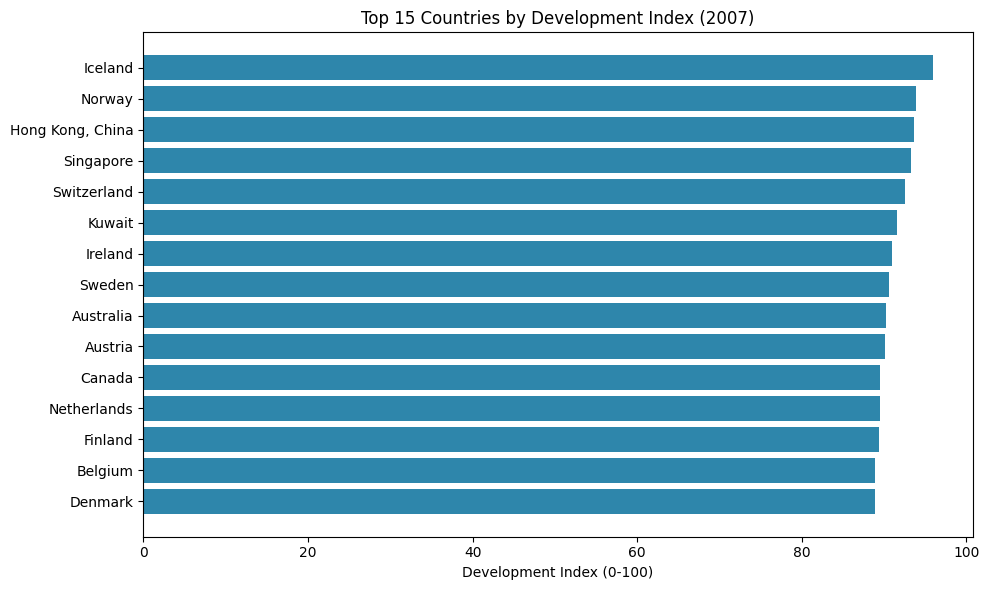

In [7]:
dv = DevelopmentVisualizer(dh.data)
dv.plot_top_countries(n=15, year=2007)

### Where does a specific country rank?

In [8]:
dh.get_country_rank('Germany', year=2007)

,rank,country,continent,year,gdpPercap,lifeExp,pop,development_index
25,26,Germany,Europe,2007,32170.37442,79.406,82400996.0,86.085532


### Extremes: highest and lowest values

Rather than only looking at the index itself, I also wanted to see which single country sits at
each extreme on the raw underlying indicators. This is a useful sanity check on the data too.

In [9]:
dh.get_extremes('gdpPercap', year=2007)

,extreme,country,continent,year,gdpPercap
0,max,Norway,Europe,2007,49357.190170
1,min,"Congo, Dem. Rep.",Africa,2007,277.551859


In [10]:
dh.get_extremes('lifeExp', year=2007)

,extreme,country,continent,year,lifeExp
0,max,Japan,Asia,2007,82.603
1,min,Swaziland,Africa,2007,39.613


### Filtering by threshold

I added a generic threshold filter so I could ask arbitrary questions like this one: which
countries had a life expectancy above 80 in 2007?

In [11]:
dh.filter_by_threshold('lifeExp', 80, comparison='greater', year=2007)

,country,continent,year,lifeExp,development_index
0,Japan,Asia,2007,82.603,88.795945
1,"Hong Kong, China",Asia,2007,82.208,93.658300
2,Iceland,Europe,2007,81.757,95.944549
3,Switzerland,Europe,2007,81.701,92.538224
4,Australia,Oceania,2007,81.235,90.176674
5,Spain,Europe,2007,80.941,87.545736
6,Sweden,Europe,2007,80.884,90.591057
7,Israel,Asia,2007,80.745,88.375794
8,France,Europe,2007,80.657,87.263371
9,Canada,Americas,2007,80.653,89.472135


And on the other end which countries scored below 30 on the Development Index (the bottom performers) in 2007?

In [12]:
dh.filter_by_threshold('development_index', 30, comparison='less', year=2007)

,country,continent,year,development_index,development_index
0,"Congo, Dem. Rep.",Africa,2007,10.598164,10.598164
1,Zimbabwe,Africa,2007,13.928888,13.928888
2,Liberia,Africa,2007,16.672049,16.672049
3,Mozambique,Africa,2007,16.783363,16.783363
4,Sierra Leone,Africa,2007,19.031215,19.031215
5,Afghanistan,Asia,2007,19.538317,19.538317
6,Central African Republic,Africa,2007,19.955260,19.955260
7,Burundi,Africa,2007,19.978044,19.978044
8,Guinea-Bissau,Africa,2007,21.198337,21.198337
9,Zambia,Africa,2007,21.469812,21.469812


## 4. Continent-level analysis

Individual country rankings only tell part of the story, so I grouped everything by continent
next to see if the patterns hold at a broader level.

In [13]:
continent_summary_2007 = dh.get_continent_summary(year=2007)
continent_summary_2007

,continent,countries,avg_gdpPercap,avg_lifeExp,avg_development_index
0,Oceania,2,29810.188275,80.719500,89.188423
1,Europe,30,25054.481636,77.648600,83.271381
2,Americas,25,11003.031625,73.608120,70.321250
3,Asia,33,12473.026870,70.728485,64.093098
4,Africa,52,3089.032605,54.806038,37.905437


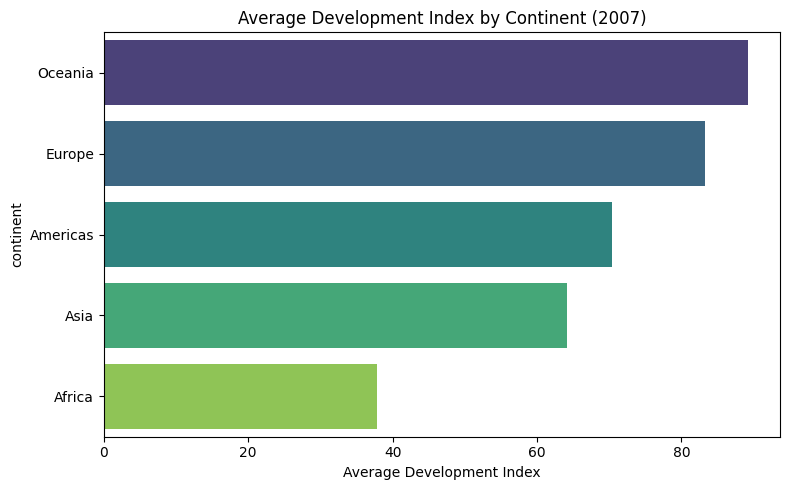

In [14]:
dv.plot_continent_comparison(year=2007)

An average can hide a lot, so I also plotted the spread within each continent. This shows how much inequality exists *within* a continent, not just between continents.

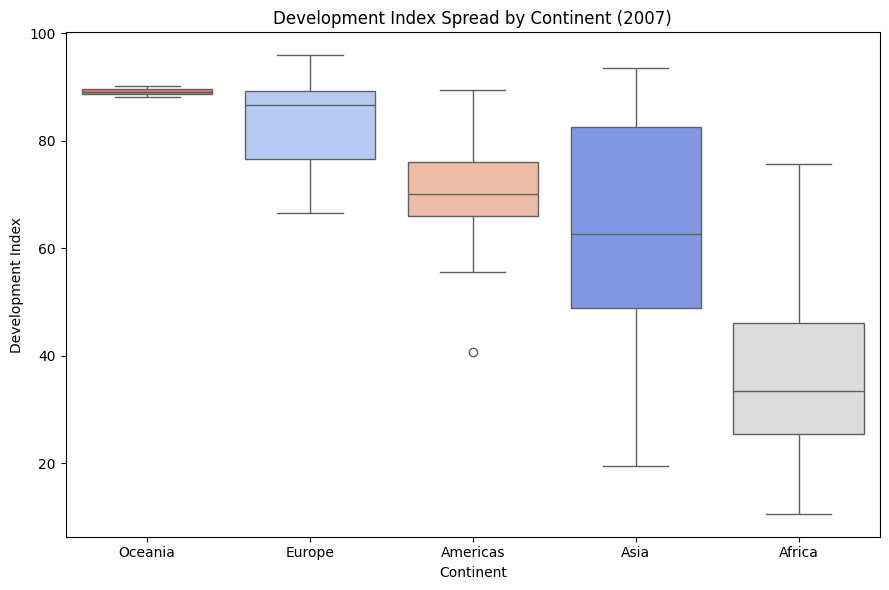

In [15]:
dv.plot_boxplot_by_continent(year=2007)

I also wanted to check how many countries each continent actually contributes to the dataset, since a continent with very few countries (like Oceania here) is easier to sway with one outlier.

In [16]:
dh.get_country_count_by_continent(year=2007)

continent
Africa      52
Asia        33
Europe      30
Americas    25
Oceania      2
Name: country, dtype: int64

### GDP quartile analysis

Instead of relying on a single correlation number, I split all countries into GDP-per-capita
quartiles (poorest 25% up to richest 25%) and compared average life expectancy and Development
Index across those buckets. This makes the relationship between wealth and health much more
concrete than a correlation coefficient alone.

In [17]:
dh.get_gdp_quartile_analysis(year=2007)

,gdp_quartile,countries,avg_gdpPercap,avg_lifeExp,avg_development_index
0,Q1 (poorest),36,986.34,53.12,29.95
1,Q2,35,3563.90,64.39,52.45
2,Q3,35,10390.38,71.56,70.20
3,Q4 (richest),36,31518.39,79.01,87.50


## 5. Country deep-dives & comparisons

I picked a few specific countries to trace individually, mostly to sanity-check that the index
behaves the way I'd expect over time.

In [18]:
dh.get_country_trend('India').tail()

,country,year,pop,continent,lifeExp,gdpPercap,gdpPercap_log,pop_log,pop_log_inv,gdpPercap_norm,lifeExp_norm,pop_log_inv_norm,development_index
7,India,1987,7.880000e+08,Asia,58.553,976.512676,6.885011,20.485009,-20.485009,0.211021,0.481039,0.034712,31.489810
8,India,1992,8.720000e+08,Asia,60.223,1164.406809,7.060825,20.586300,-20.586300,0.262230,0.656803,0.031717,41.673683
9,India,1997,9.590000e+08,Asia,61.765,1458.817442,7.286067,20.681402,-20.681402,0.315330,0.575701,0.027532,40.371733
10,India,2002,1.034173e+09,Asia,62.879,1746.769454,7.466096,20.756867,-20.756867,0.378796,0.553321,0.023930,42.184577
11,India,2007,1.110396e+09,Asia,64.698,2452.210407,7.805153,20.827983,-20.827983,0.420213,0.583508,0.019545,45.362876


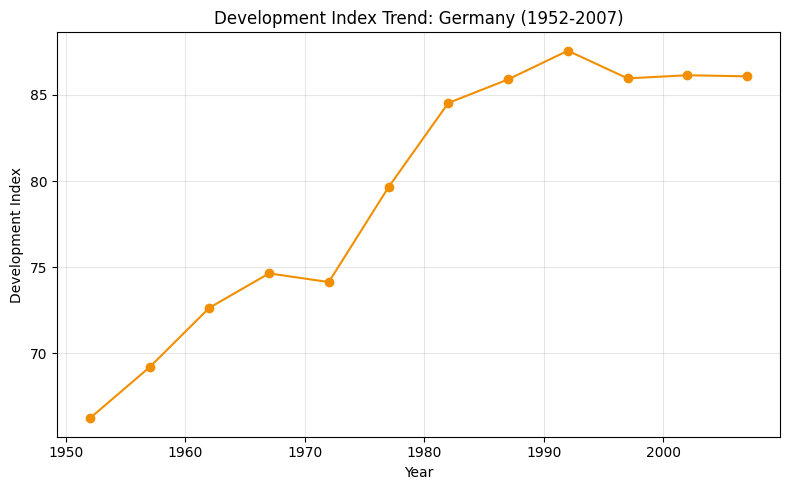

In [19]:
dv.plot_trend('Germany')

Then I compared several countries on the same chart, which makes relative growth rates much easier to see than looking at each one separately:

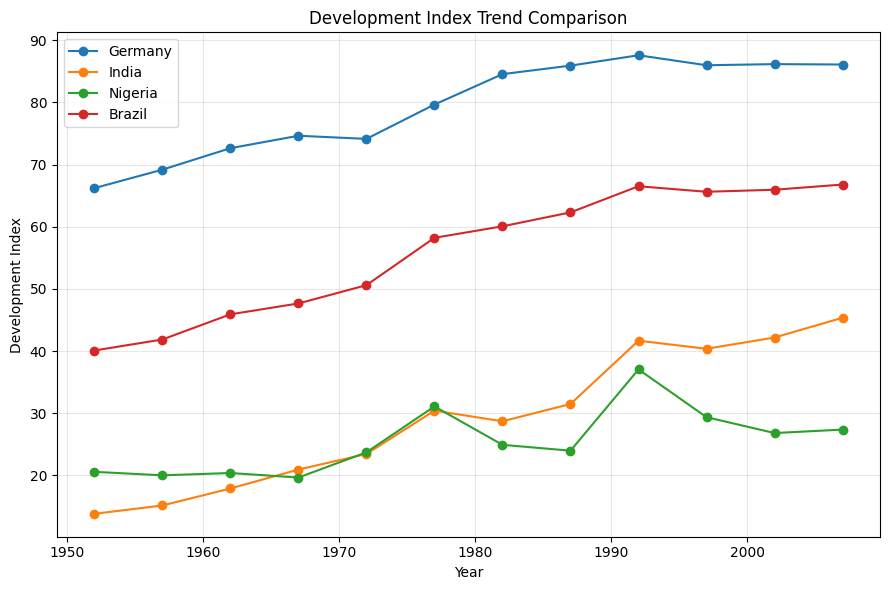

In [20]:
dv.plot_multi_country_trend(['Germany', 'India', 'Nigeria', 'Brazil'])

Here's the raw comparison table behind that chart, in case the exact numbers matter more than the visual trend:

In [21]:
dh.compare_countries(['Germany', 'India', 'Nigeria', 'Brazil'])[
    ['country', 'year', 'gdpPercap', 'lifeExp', 'development_index']
]

,country,year,gdpPercap,lifeExp,development_index
0,Brazil,1952,2108.944355,50.917,40.094395
1,Brazil,1957,2487.365989,53.285,41.862386
2,Brazil,1962,3336.585802,55.665,45.911395
3,Brazil,1967,3429.864357,57.632,47.658924
4,Brazil,1972,4985.711467,59.504,50.601800
5,Brazil,1977,6660.118654,61.489,58.217424
6,Brazil,1982,7030.835878,63.336,60.066029
7,Brazil,1987,7807.095818,65.205,62.305483
8,Brazil,1992,6950.283021,67.057,66.509552
9,Brazil,1997,7957.980824,69.388,65.620216


## 6. Correlation & distribution analysis

I wanted to check how strongly GDP per capita, life expectancy, and population actually relate
to the Development Index I built partly to validate the weighting choices I made earlier.

In [22]:
dh.get_correlation_matrix(year=2007)

,gdpPercap,lifeExp,pop,development_index
gdpPercap,1.000,0.679,-0.056,0.816
lifeExp,0.679,1.000,0.048,0.948
pop,-0.056,0.048,1.000,-0.027
development_index,0.816,0.948,-0.027,1.000


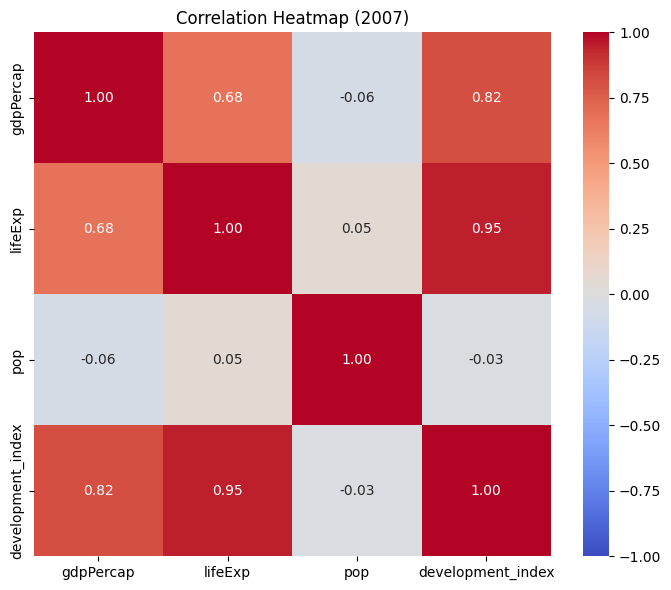

In [23]:
dv.plot_correlation_heatmap(year=2007)

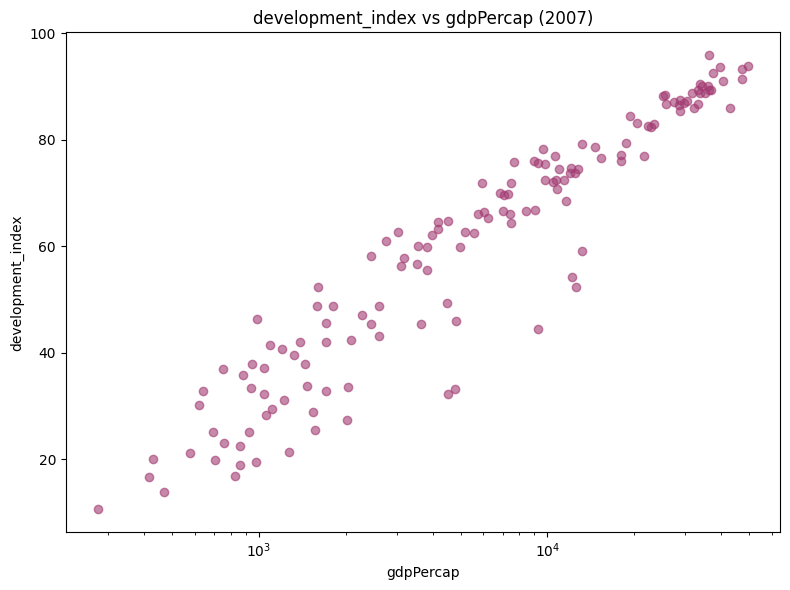

In [24]:
dv.plot_correlation(x='gdpPercap', y='development_index', year=2007)

I also looked at how the index is distributed across all countries in a single year, to check it isn't skewed too heavily toward one end:

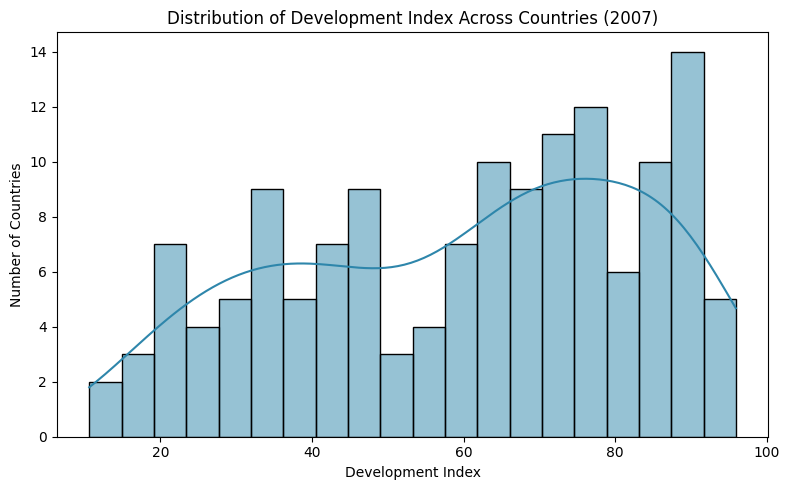

In [25]:
dv.plot_distribution(year=2007)

## 7. Biggest movers: 1952 vs 2007

Since the dataset spans over 50 years, I wanted to know which countries changed the most for
better or worse across the full period, not just where they rank today.

In [26]:
biggest_gainers = dh.get_biggest_movers(1952, 2007, n=10)
biggest_gainers

,country,change,index_1952,index_2007
0,Oman,52.174965,30.481087,82.656052
1,"Korea, Rep.",50.907377,32.162547,83.069923
2,China,42.115872,17.820236,59.936108
3,Taiwan,39.807074,45.681027,85.488101
4,Indonesia,38.610161,17.996880,56.607041
5,Singapore,38.473943,54.817720,93.291663
6,Equatorial Guinea,38.027529,16.162597,54.190126
7,Libya,37.784856,37.033776,74.818632
8,Vietnam,37.611051,20.629723,58.240773
9,"Hong Kong, China",36.840445,56.817855,93.658300


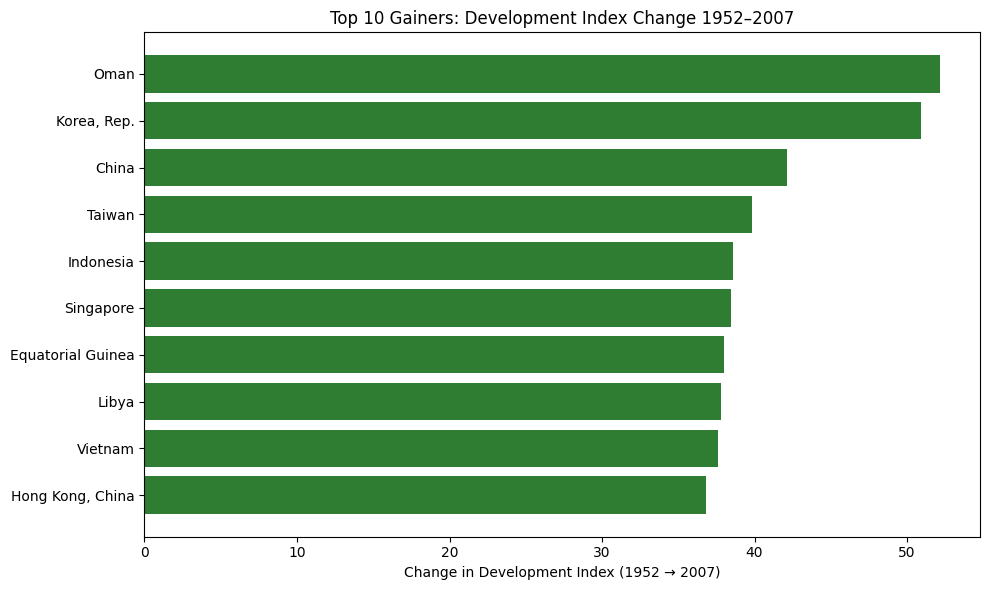

In [27]:
dv.plot_biggest_movers(1952, 2007, n=10)

In [28]:
biggest_decliners = dh.get_biggest_movers(1952, 2007, n=10, ascending=True)
biggest_decliners

,country,change,index_1952,index_2007
0,Zimbabwe,-14.266975,28.195863,13.928888
1,"Congo, Dem. Rep.",-11.352752,21.950916,10.598164
2,Zambia,-8.211871,29.681682,21.469812
3,Liberia,-5.332805,22.004854,16.672049
4,Central African Republic,-3.253990,23.209250,19.955260
5,Cote d'Ivoire,-0.520304,29.418656,28.898351
6,Swaziland,0.765317,31.471190,32.236506
7,Rwanda,1.257382,21.208968,22.466350
8,Burundi,2.576315,17.401729,19.978044
9,South Africa,2.807159,41.704322,44.511481


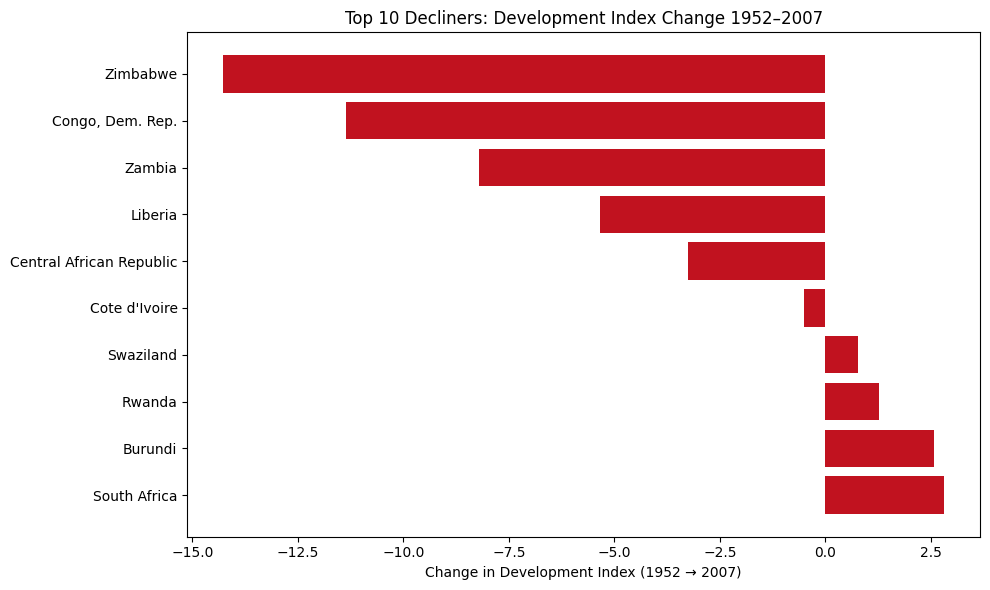

In [29]:
dv.plot_biggest_movers(1952, 2007, n=10, ascending=True)

### Percentage change vs. absolute change

I realized ranking by absolute point change favors countries that were already mid-range in
1952 a country starting near zero can post a huge percentage gain while looking modest on the
absolute scale. So I added a second ranking based on percentage change to see if the story
changes.

In [30]:
dh.get_percentage_change_leaders(1952, 2007, n=10)

,country,index_1952,index_2007,pct_change
0,China,17.820236,59.936108,236.337337
1,Equatorial Guinea,16.162597,54.190126,235.281051
2,India,13.834293,45.362876,227.901665
3,Indonesia,17.996880,56.607041,214.538085
4,Myanmar,12.125604,37.896126,212.529793
5,"Yemen, Rep.",16.340291,47.087016,188.165100
6,Vietnam,20.629723,58.240773,182.314864
7,Gambia,13.220164,36.987159,179.778365
8,Oman,30.481087,82.656052,171.171604
9,"Korea, Rep.",32.162547,83.069923,158.281549


I also wanted to see the big picture: has the world *on average* gotten more developed by this measure over time?

In [31]:
dh.get_global_yearly_trend()

,year,avg_development_index
0,1952,40.503661
1,1957,42.142461
2,1962,44.477055
3,1967,47.220413
4,1972,48.628287
5,1977,54.455526
6,1982,55.289009
7,1987,56.443345
8,1992,61.998464
9,1997,58.830274


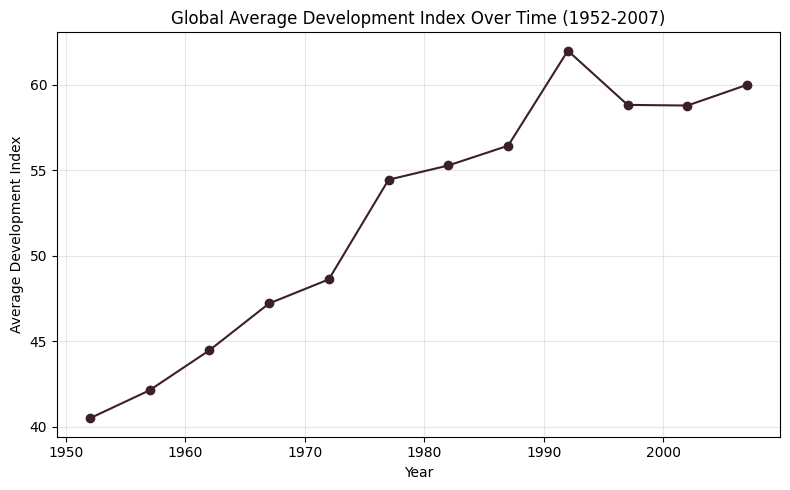

In [32]:
dv.plot_global_trend()

### Averages by decade

The year-by-year trend above is a little noisy, so I bucketed the years into decades to make the
long-run pattern easier to read at a glance.

In [33]:
dh.get_decade_averages()

,decade_label,avg_gdpPercap,avg_lifeExp,avg_development_index,num_country_year_rows
0,1950s,4012.34,50.28,41.32,284
1,1960s,5104.73,54.64,45.85,284
2,1970s,7041.62,58.61,51.54,284
3,1980s,7709.91,62.37,55.87,284
4,1990s,8624.39,64.59,60.41,284
5,2000s,10798.96,66.35,59.40,284


## 8. Custom weighting experiment

My default weights are GDP per capita = 0.45, Life expectancy = 0.45, Population (log, inverted)
= 0.10. I chose to weight GDP and life expectancy equally since I didn't want the index to be
dominated by wealth alone. To check how sensitive the rankings are to that choice, I re-ran the
index with GDP weighted much more heavily to see who moves up or down:

In [34]:
custom_weights = {'gdpPercap': 0.6, 'lifeExp': 0.35, 'pop_log_inv': 0.05}
dh.compute_development_index(weights=custom_weights)
dh.get_top_countries(n=10, year=2007)

,rank,country,continent,year,gdpPercap,lifeExp,pop,development_index
0,1,Norway,Europe,2007,49357.19017,80.196,4627926.0,96.253367
1,2,Singapore,Asia,2007,47143.17964,79.972,4553009.0,95.548414
2,3,Iceland,Europe,2007,36180.78919,81.757,301931.0,95.476921
3,4,"Hong Kong, China",Asia,2007,39724.97867,82.208,6980412.0,95.141806
4,5,Switzerland,Europe,2007,37506.41907,81.701,7554661.0,94.018107
5,6,Kuwait,Asia,2007,47306.98978,77.588,2505559.0,93.987214
6,7,Ireland,Europe,2007,40675.99635,78.885,4109086.0,93.011802
7,8,Australia,Oceania,2007,34435.36744,81.235,20434176.0,92.083079
8,9,Sweden,Europe,2007,33859.74835,80.884,9031088.0,92.066115
9,10,Austria,Europe,2007,36126.49270,79.829,8199783.0,92.013037


## Conclusions

- The Development Index correlates most strongly with **life expectancy**, followed by GDP per capita population size has almost no effect once log-scaled and inverted. This matched what I expected, but it was good to confirm it rather than assume it.
- **Europe and Oceania** lead in average Development Index, **Africa** trails, though individual countries vary widely (see the boxplot spread). The averages alone would have hidden that variation.
- Countries like **Oman, South Korea, and China** show the largest gains from 1952 to 2007, reflecting rapid post-war and post-industrialization development.
- A handful of countries (e.g. **Zimbabwe, DR Congo**) saw their index *decline* over the same period, usually tied to periods of conflict or economic instability.
- Switching to GDP-heavy weights in the final experiment shifted a few rankings but didn't change the overall leaders much, which gave me some confidence that the index isn't overly sensitive to the exact weight choices.
